In [21]:
import sys
sys.path.append("../utils/py")
import miniramses as ram

In [28]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import miniramses as ram
from miniramses import visu

# -----------------------------
# Matplotlib config
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 300
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
    "text.usetex": False,
})

# -----------------------------
# Global settings
# -----------------------------
center = np.array([1, 1, 1])


# -----------------------------
# Utilities
# -----------------------------
def normalize_dir(path):
    """Normalize path safely."""
    return os.path.abspath(path)


def infer_isort(prefix):
    """Validate prefix."""
    if prefix is None:
        prefix = "hydro"

    prefix = prefix.lower()

    if prefix in ["hydro", "grav", "rt"]:
        return 0
    elif prefix == "peak":
        return 1
    else:
        raise ValueError(f"Unknown prefix: {prefix}")


def read_output(output_path, center=center):
    """
    Read RAMSES output from full directory path.

    Example:
        /home/.../mini-ramses/output_00004
    """
    output_path = normalize_dir(output_path)

    nout_dir = os.path.basename(output_path)
    base_path = os.path.dirname(output_path)

    if not nout_dir.startswith("output_"):
        raise ValueError(
            f"Expected path like '.../output_00004', got: {output_path}"
        )

    nout = nout_dir.split("_")[-1]
    print("I am reading nout: ", nout)

    candidate_prefixes = ["grav", "hydro", "rt", "peak"]
    last_err = None

    for prefix in candidate_prefixes:
        try:
            infer_isort(prefix)

            c = ram.rd_cell(nout, path=base_path, prefix=prefix, center=center)
            i = ram.rd_info(nout, path=base_path)

            print(f"[OK] {output_path} (prefix='{prefix}')")
            return c, i, prefix

        except Exception as err:
            last_err = err

    raise RuntimeError(
        f"Failed to read {output_path} with known prefixes.\nLast error: {last_err}"
    )




def _display_shift_for_box(x, y, dx, box):
    if box is None:
        half_dx = 0.5 * np.asarray(dx, dtype=float)
        x0 = float(np.nanmin(np.asarray(x, dtype=float) - half_dx))
        x1 = float(np.nanmax(np.asarray(x, dtype=float) + half_dx))
        y0 = float(np.nanmin(np.asarray(y, dtype=float) - half_dx))
        y1 = float(np.nanmax(np.asarray(y, dtype=float) + half_dx))
    else:
        x0, x1, y0, y1 = map(float, box)
    return -x0, -y0, [0.0, x1 - x0, 0.0, y1 - y0]

def _shift_display_xy(x, y, dx, box):
    x_shift, y_shift, display_box = _display_shift_for_box(x, y, dx, box)
    return x + x_shift, y + y_shift, display_box

def amr_slice(c, cen, levels=None):
    """
    Select cells intersecting plane z = cen.
    """
    mask = np.abs(c.x[2] - cen) <= c.dx / 2

    if levels is not None:
        mask &= np.isin(c.level, levels)

    x = c.x[0][mask]
    y = c.x[1][mask]
    dx = c.dx[mask]

    return x, y, dx, mask


# -----------------------------
# Plot single output
# -----------------------------
def plot(output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Plot one output.

    Parameters
    ----------
    output_path : str
        Path to output directory
    cen : float
        z-slice center
    levels : list or None
        AMR levels to include
    field_index : int
        which component of c.g to plot
    """

    print("Reading:", output_path)

    c, i, prefix = read_output(output_path, center=center)

    print("Levels:", np.unique(c.level))
    x, y, dx, mask = amr_slice(c, cen, levels)

    val = c.g[field_index][mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    return ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)


# -----------------------------
# Compare two outputs
# -----------------------------
def compare(output_path, base_output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Compare two outputs (difference plot).
    """

    print("Target:", output_path)
    print("Base  :", base_output_path)

    c, _, _ = read_output(output_path, center=center)
    c_base, _, _ = read_output(base_output_path, center=center)

    x, y, dx, mask = amr_slice(c, cen, levels)

    diff = c.g[field_index] - c_base.g[field_index]
    val = diff[mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    out = ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)

    denom = c_base.g[field_index][mask]
    good = denom != 0

    if np.any(good):
        rel = val[good] / denom[good]
        print("mean relative error :", np.mean(rel))
        print("median relative error:", np.median(rel))
    else:
        print("Relative error undefined (denominator zero everywhere)")

    return out

In [29]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import miniramses as ram

# -----------------------------
# Matplotlib config
# -----------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 800
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
})

# -----------------------------
# Global settings
# -----------------------------
center = np.array([1, 1, 1])


# -----------------------------
# Utilities
# -----------------------------
def normalize_dir(path):
    """Normalize path safely."""
    return os.path.abspath(path)


def infer_isort(prefix):
    """Validate prefix."""
    if prefix is None:
        prefix = "hydro"

    prefix = prefix.lower()

    if prefix in ["hydro", "grav", "rt"]:
        return 0
    elif prefix == "peak":
        return 1
    else:
        raise ValueError(f"Unknown prefix: {prefix}")


def read_output(output_path, center=center):
    """
    Read RAMSES output from full directory path.

    Example:
        /home/.../mini-ramses/output_00004
    """
    output_path = normalize_dir(output_path)

    nout_dir = os.path.basename(output_path)
    base_path = os.path.dirname(output_path)

    if not nout_dir.startswith("output_"):
        raise ValueError(
            f"Expected path like '.../output_00004', got: {output_path}"
        )

    nout = nout_dir.split("_")[-1]
    print("I am reading nout: ", nout)

    candidate_prefixes = ["grav", "hydro", "rt", "peak"]
    last_err = None

    for prefix in candidate_prefixes:
        try:
            infer_isort(prefix)

            c = ram.rd_cell(nout, path=base_path, prefix=prefix, center=center)
            i = ram.rd_info(nout, path=base_path)

            print(f"[OK] {output_path} (prefix='{prefix}')")
            return c, i, prefix

        except Exception as err:
            last_err = err

    raise RuntimeError(
        f"Failed to read {output_path} with known prefixes.\nLast error: {last_err}"
    )




def _display_shift_for_box(x, y, dx, box):
    if box is None:
        half_dx = 0.5 * np.asarray(dx, dtype=float)
        x0 = float(np.nanmin(np.asarray(x, dtype=float) - half_dx))
        x1 = float(np.nanmax(np.asarray(x, dtype=float) + half_dx))
        y0 = float(np.nanmin(np.asarray(y, dtype=float) - half_dx))
        y1 = float(np.nanmax(np.asarray(y, dtype=float) + half_dx))
    else:
        x0, x1, y0, y1 = map(float, box)
    return -x0, -y0, [0.0, x1 - x0, 0.0, y1 - y0]

def _shift_display_xy(x, y, dx, box):
    x_shift, y_shift, display_box = _display_shift_for_box(x, y, dx, box)
    return x + x_shift, y + y_shift, display_box

def amr_slice(c, cen, levels=None):
    """
    Select cells intersecting plane z = cen.
    """
    mask = np.abs(c.x[2] - cen) <= c.dx / 2

    if levels is not None:
        mask &= np.isin(c.level, levels)

    x = c.x[0][mask]
    y = c.x[1][mask]
    dx = c.dx[mask]

    return x, y, dx, mask


# -----------------------------
# Plot single output
# -----------------------------
def plot(output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Plot one output.
    """

    print("Reading:", output_path)

    c, i, prefix = read_output(output_path, center=center)

    print("Levels:", np.unique(c.level))
    x, y, dx, mask = amr_slice(c, cen, levels)

    val = c.g[field_index][mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    return ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)


# -----------------------------
# Compare two outputs
# -----------------------------
def compare(output_path, base_output_path, cen=600, levels=None, field_index=0, **visu_kwargs):
    """
    Compare two outputs.

    Difference is target - base.
    """

    print("Target:", output_path)
    print("Base  :", base_output_path)

    c, _, _ = read_output(output_path, center=center)
    c_base, _, _ = read_output(base_output_path, center=center)

    x, y, dx, mask = amr_slice(c, cen, levels)

    diff = c.g[field_index] - c_base.g[field_index]
    val = diff[mask]
    lev = c.level[mask]

    box = visu_kwargs.get("box", None)
    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)
    visu_kwargs = dict(visu_kwargs)
    visu_kwargs["box"] = display_box

    out = ram.visu(x_plot, y_plot, dx, val, lev, **visu_kwargs)

    denom = c_base.g[field_index][mask]
    good = denom != 0

    if np.any(good):
        rel = val[good] / denom[good]
        print("mean relative error :", np.mean(rel))
        print("median relative error:", np.median(rel))
    else:
        print("Relative error undefined, denominator zero everywhere")

    return out

In [30]:
def panel_mpi_gpu_percent(
    gpu_output_path,
    mpi_output_path,
    cen=600,
    levels=None,
    field_index=0,
    vmin=None,
    vmax=None,
    diff_vmin=-10,
    diff_vmax=10,
    cmap="magma",
    diff_cmap="RdBu_r",
    npix=1200,
    grid=True,
    box=None,
    figsize=(15, 5),
    phi_label="x",
    gpu_label="GPU",
    mpi_label="MPI",
    save=None,
):
    """
    Three-panel plot:

        mpi_label | gpu_label | 100 * (mpi_label - gpu_label) / mpi_label

    Positive percent means mpi_label > gpu_label.
    """

    print(f"Reading {gpu_label}:", gpu_output_path)
    c_gpu, _, _ = read_output(gpu_output_path, center=cen)

    print(f"Reading {mpi_label}:", mpi_output_path)
    c_mpi, _, _ = read_output(mpi_output_path, center=cen)

    print(f"{gpu_label} levels:", np.unique(c_gpu.level))
    print(f"{mpi_label} levels:", np.unique(c_mpi.level))

    # Use GPU slice geometry
    x, y, dx, mask = amr_slice(c_gpu, cen, levels)
    lev = c_gpu.level[mask]

    gpu_val = c_gpu.g[field_index][mask]
    mpi_val = c_mpi.g[field_index][mask]

    x_plot, y_plot, display_box = _shift_display_xy(x, y, dx, box)

    # Percent difference
    percent = np.full_like(mpi_val, np.nan, dtype=float)
    good = mpi_val != 0.0
    percent[good] = 100.0 * (mpi_val[good] - gpu_val[good]) / mpi_val[good]

    print(f"Percent difference: 100 * ({mpi_label} - {gpu_label}) / {mpi_label}")
    if np.any(np.isfinite(percent)):
        print("mean percent difference   :", np.nanmean(percent))
        print("median percent difference :", np.nanmedian(percent))
        print("min percent difference    :", np.nanmin(percent))
        print("max percent difference    :", np.nanmax(percent))
    else:
        print("Percent difference undefined")

    # Absolute summary stats for annotation
    finite_percent = percent[np.isfinite(percent)]
    if finite_percent.size > 0:
        max_abs_percent = np.nanmax(np.abs(finite_percent))
        mean_abs_percent = np.nanmean(np.abs(finite_percent))
    else:
        max_abs_percent = np.nan
        mean_abs_percent = np.nan

    # Shared MPI/GPU scale
    if vmin is None:
        vmin = np.nanmin([np.nanmin(mpi_val), np.nanmin(gpu_val)])
    if vmax is None:
        vmax = np.nanmax([np.nanmax(mpi_val), np.nanmax(gpu_val)])

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize,
        dpi=300,
        constrained_layout=True,
    )

    # -----------------------------
    # MPI
    # -----------------------------
    _, _, im0 = visu(
        x_plot,
        y_plot,
        dx,
        mpi_val,
        lev,
        ax=axes[0],
        npix=npix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        box=display_box,
        grid=grid,
        colorbar=False,
    )
    axes[0].set_title(mpi_label)
    axes[0].set_xlabel(r"$x$")
    axes[0].set_ylabel(r"$y$")

    # -----------------------------
    # GPU
    # -----------------------------
    _, _, im1 = visu(
        x_plot,
        y_plot,
        dx,
        gpu_val,
        lev,
        ax=axes[1],
        npix=npix,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        box=display_box,
        grid=grid,
        colorbar=False,
    )
    axes[1].set_title(gpu_label)
    axes[1].set_xlabel(r"$x$")

    # -----------------------------
    # Percentage difference
    # -----------------------------
    _, _, im2 = visu(
        x_plot,
        y_plot,
        dx,
        percent,
        lev,
        ax=axes[2],
        npix=npix,
        cmap=diff_cmap,
        vmin=diff_vmin,
        vmax=diff_vmax,
        box=display_box,
        grid=grid,
        colorbar=False,
    )
    axes[2].set_xlabel(r"$x$")

    axes[2].text(
        0.5,
        1.00,
        rf"max: {max_abs_percent:.2e}$\%$, mean: {mean_abs_percent:.2e}$\%$",
        transform=axes[2].transAxes,
        ha="center",
        va="bottom",
        fontsize=20,
    )

    axes[1].set_yticks([])
    axes[2].set_yticks([])

    # Shared colorbar for MPI and GPU
    cbar0 = fig.colorbar(
        im0,
        ax=axes[:2],
        shrink=0.82,
        pad=0.02,
    )
    cbar0.set_label(rf"$\Phi$")

    # Colorbar for percent panel
    cbar1 = fig.colorbar(
        im2,
        ax=axes[2],
        shrink=0.82,
        pad=0.02,
    )
    cbar1.set_label(f"100(Phi_{mpi_label} - Phi_{gpu_label}) / Phi_{mpi_label} [%]")

    if save is not None:
        fig.savefig(save, bbox_inches="tight", dpi=300)
        print(f"Saved figure to {save}")

    return fig, axes

Reading: /home/jl4415/Ramses-FMM/halo_test/runs/8890220_fmm_gpu_mpi_unigrid/gpu/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=7
Time= 0.00169893830955904
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 262144 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/8890220_fmm_gpu_mpi_unigrid/gpu/output_00002 (prefix='grav')
Levels: [6]
subset value range: -105335.453125 -28057.0703125
image range: -105335.453125 -28057.603515625
spatial box: [0.0, 100.0, 0.0, 100.0]


(<Figure size 1200x1200 with 2 Axes>,
 <AxesSubplot:>,
 <matplotlib.image.AxesImage at 0x1519bab5c0a0>)

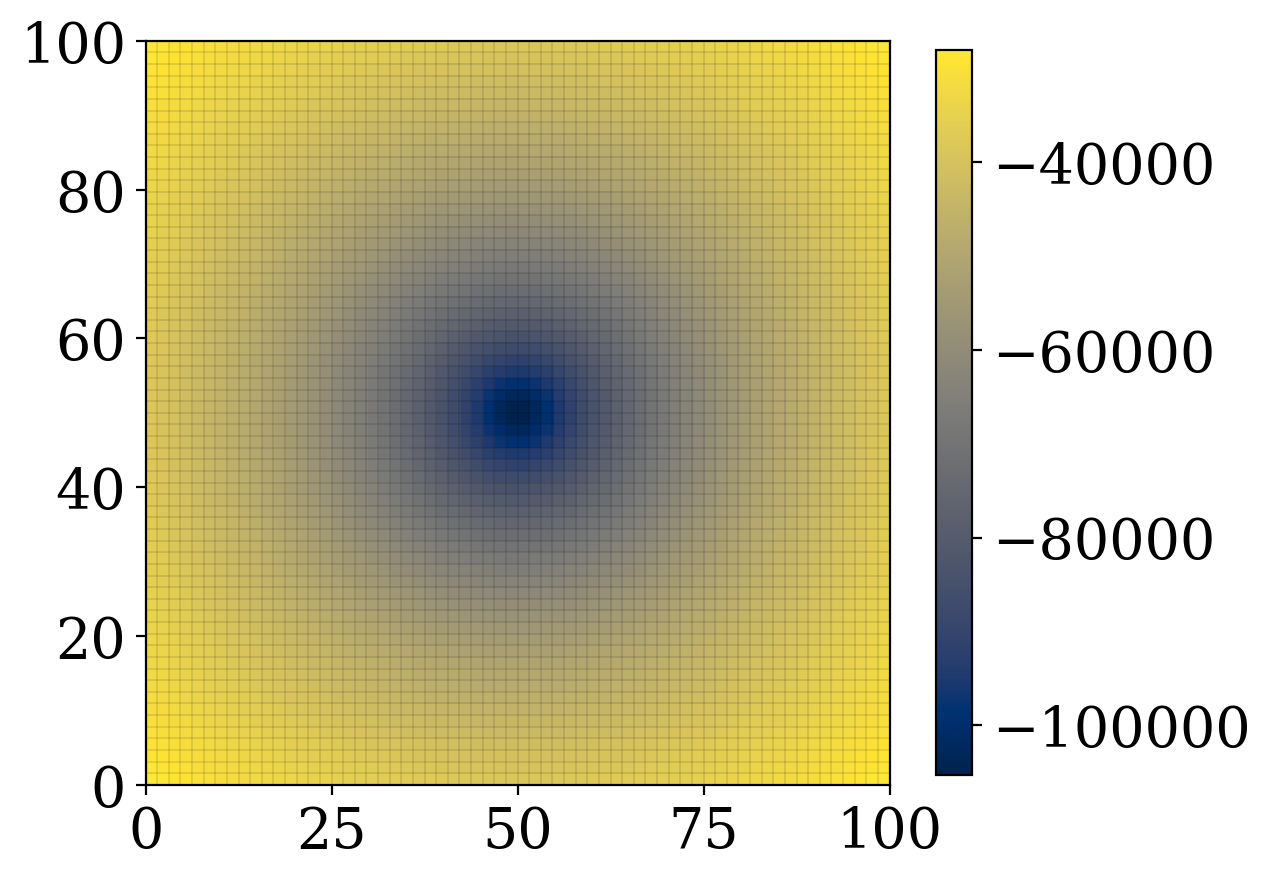

In [31]:
out1 = "/home/jl4415/Ramses-FMM/halo_test/runs/8890220_fmm_gpu_mpi_unigrid/gpu/output_00002/"

plot(
    out1,
    cen=100.0,
    cmap="cividis",
    grid=True
)

Reading GPU: /home/jl4415/Ramses-FMM/halo_test/runs/9024189_fmm_gpu_amr/fmm/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/9024189_fmm_gpu_amr/fmm/output_00002 (prefix='grav')
Reading MPI: /home/jl4415/Ramses-FMM/halo_test/runs/8891572_fmm_mpi_amr/fmm/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/8891572_fmm_mpi_amr/fmm/output_00002 (prefix='grav')
GPU levels: [6 7 8 9]
MPI levels: [6 7 8 9]
Percent difference: 100 * (MPI - GPU) / MPI
mean percent difference   : -0.000376740

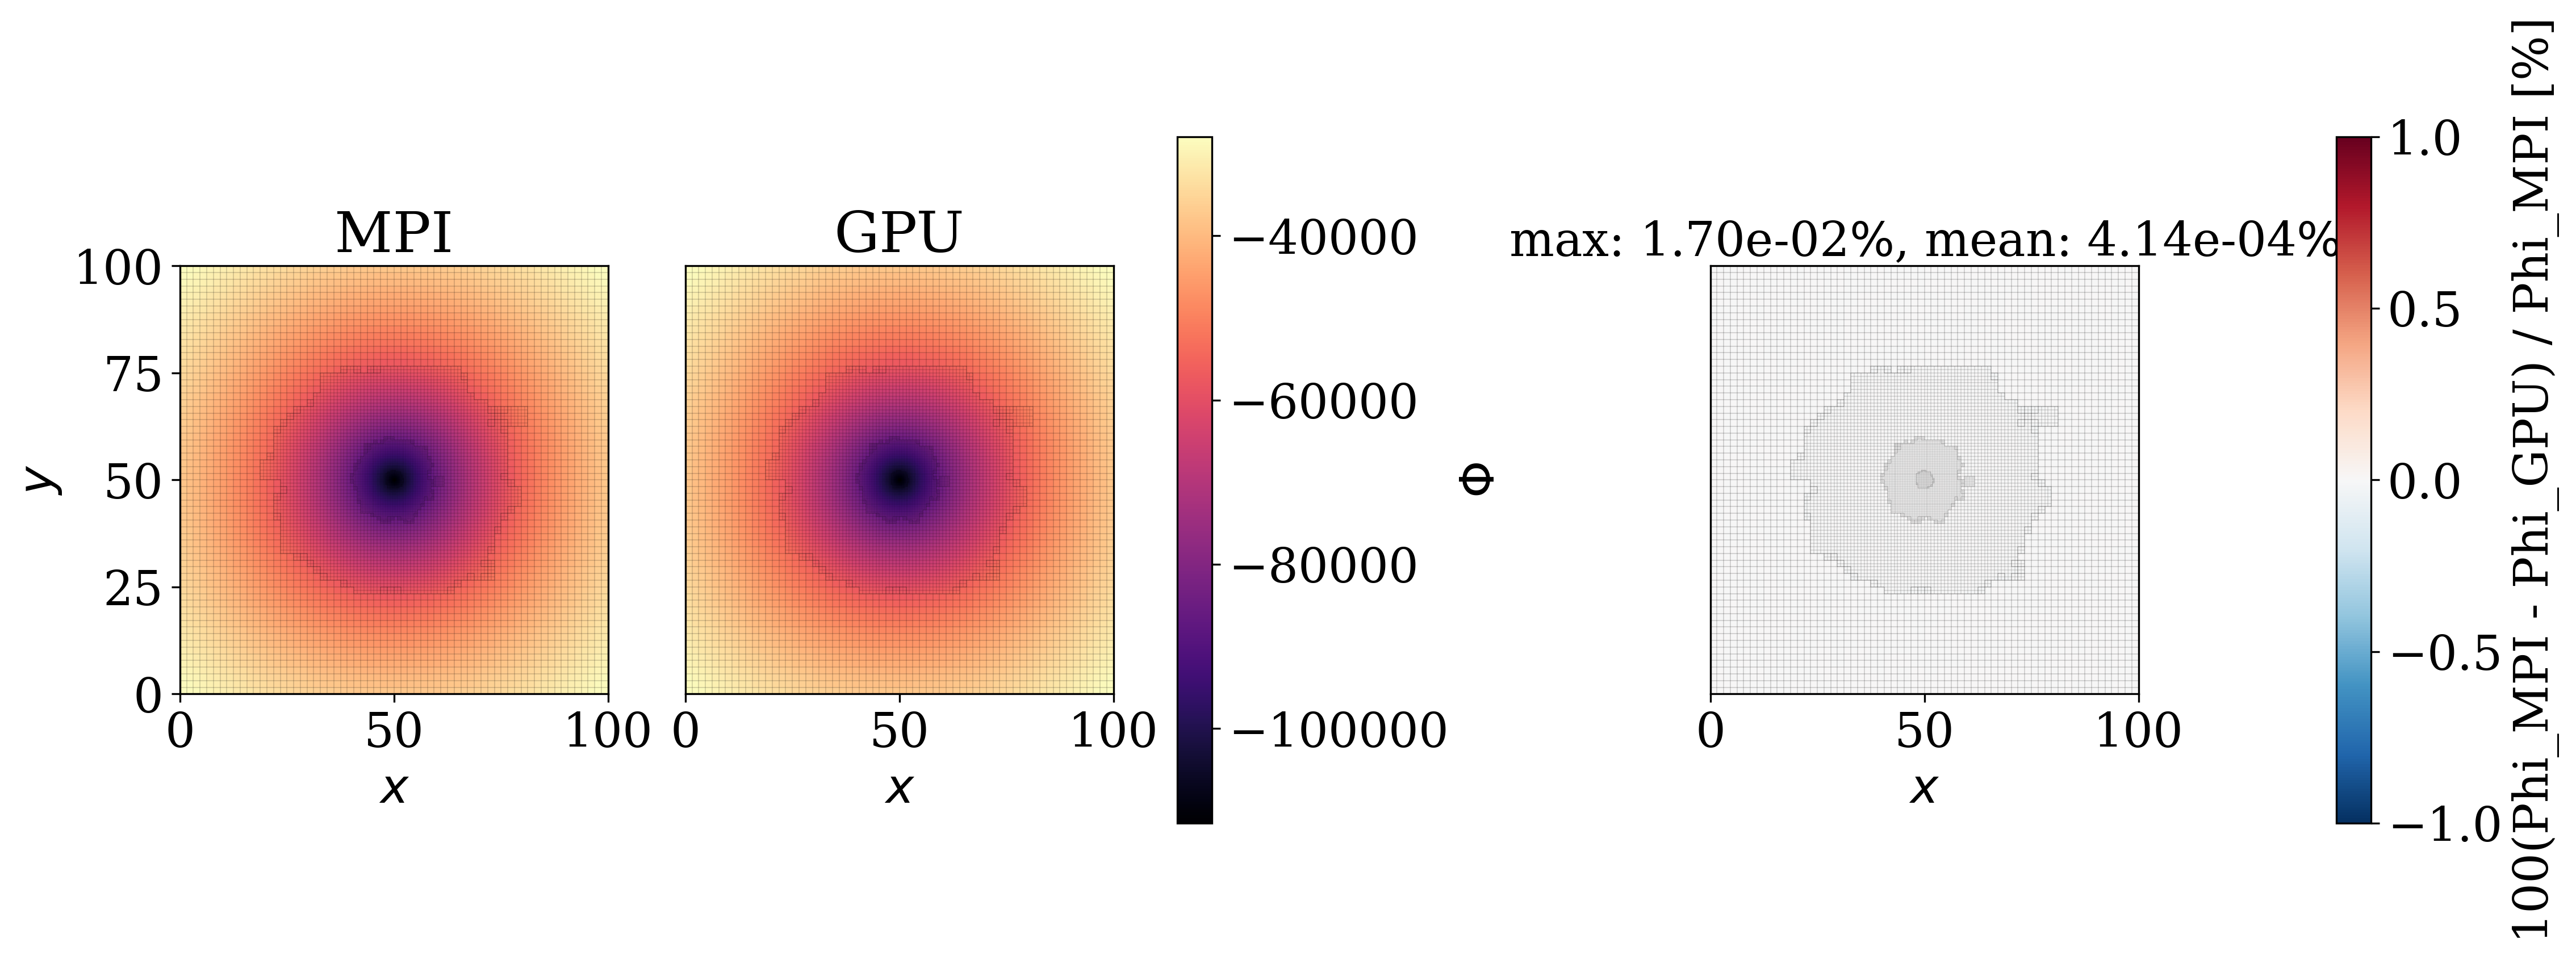

In [32]:
out1 = "/home/jl4415/Ramses-FMM/halo_test/runs/9024189_fmm_gpu_amr/fmm/output_00002/"
out2 = "/home/jl4415/Ramses-FMM/halo_test/runs/8891572_fmm_mpi_amr/fmm/output_00002/"

fig, axes = panel_mpi_gpu_percent(
    gpu_output_path=out1,
    mpi_output_path=out2,
    cen=100,
    field_index=0,
    diff_vmin=-1,
    diff_vmax=1,
    save="gpu_cpu_comparison_halo_amr.png"
)

Reading GPU: /home/jl4415/Ramses-FMM/halo_test/runs/9028480_mg_isolated/mg/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/9028480_mg_isolated/mg/output_00002 (prefix='grav')
Reading MPI: /home/jl4415/Ramses-FMM/halo_test/runs/manual_mg_cpu_amr/cpu/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/manual_mg_cpu_amr/cpu/output_00002 (prefix='grav')
GPU levels: [6 7 8 9]
MPI levels: [6 7 8 9]
Percent difference: 100 * (MPI - GPU) / MPI
mean percent difference   : -4.422717717577184

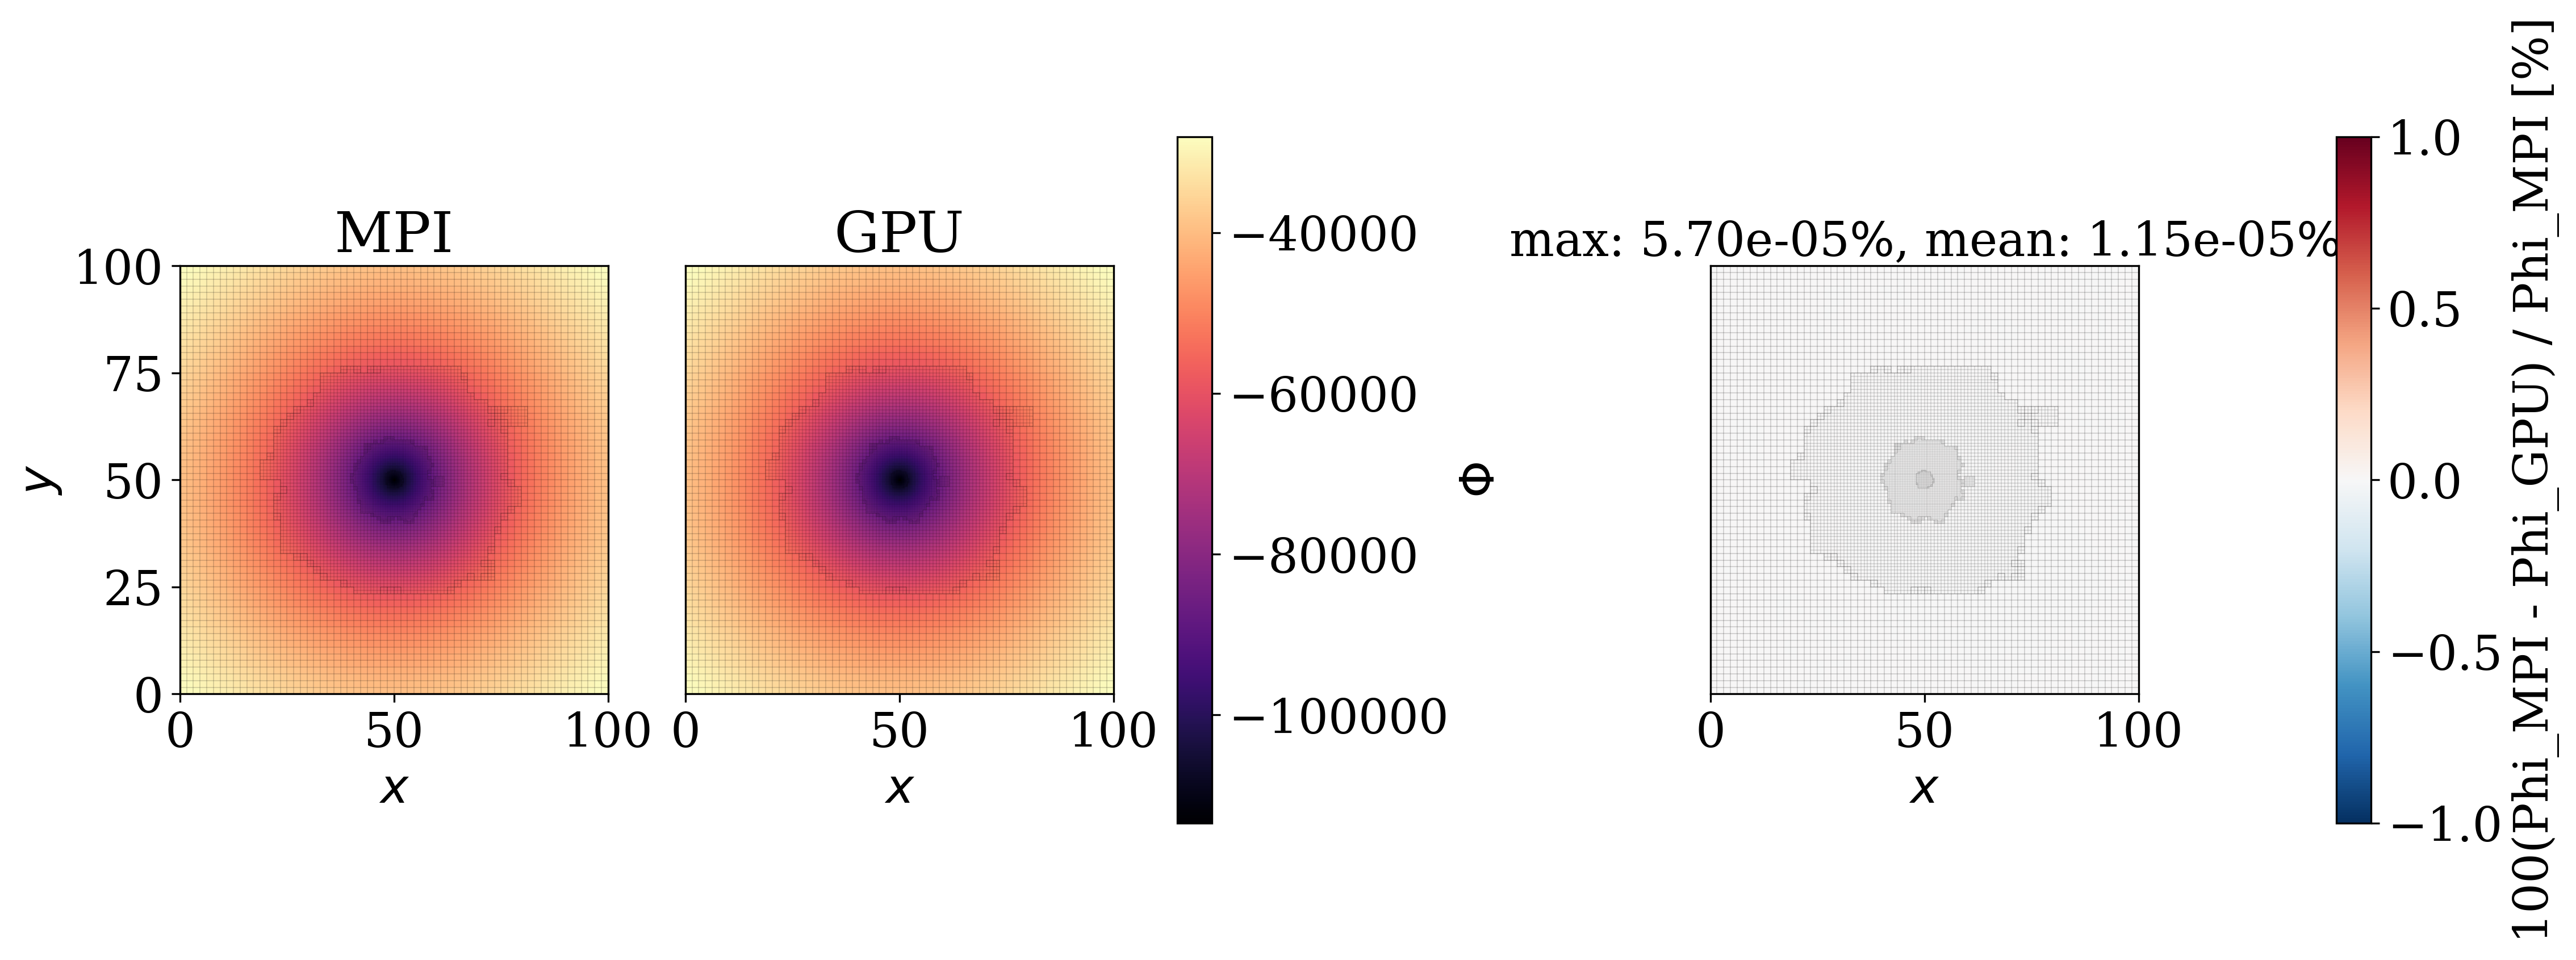

In [33]:
# MG GPU vs CPU/MPI AMR comparison.
out1 = "/home/jl4415/Ramses-FMM/halo_test/runs/9028480_mg_isolated/mg/output_00002/"
out2 = "/home/jl4415/Ramses-FMM/halo_test/runs/manual_mg_cpu_amr/cpu/output_00002/"

fig, axes = panel_mpi_gpu_percent(
    gpu_output_path=out1,
    mpi_output_path=out2,
    cen=100,
    field_index=0,
    diff_vmin=-1,
    diff_vmax=1,
    save="gpu_cpu_comparison_halo_mg_amr.png"
)

Reading FMM GPU: /home/jl4415/Ramses-FMM/halo_test/runs/9024189_fmm_gpu_amr/fmm/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/9024189_fmm_gpu_amr/fmm/output_00002 (prefix='grav')
Reading MG GPU: /home/jl4415/Ramses-FMM/halo_test/runs/9028480_mg_isolated/mg/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/9028480_mg_isolated/mg/output_00002 (prefix='grav')
FMM GPU levels: [6 7 8 9]
MG GPU levels: [6 7 8 9]
Percent difference: 100 * (MG GPU - FMM GPU) / MG GPU
mean percent diffe

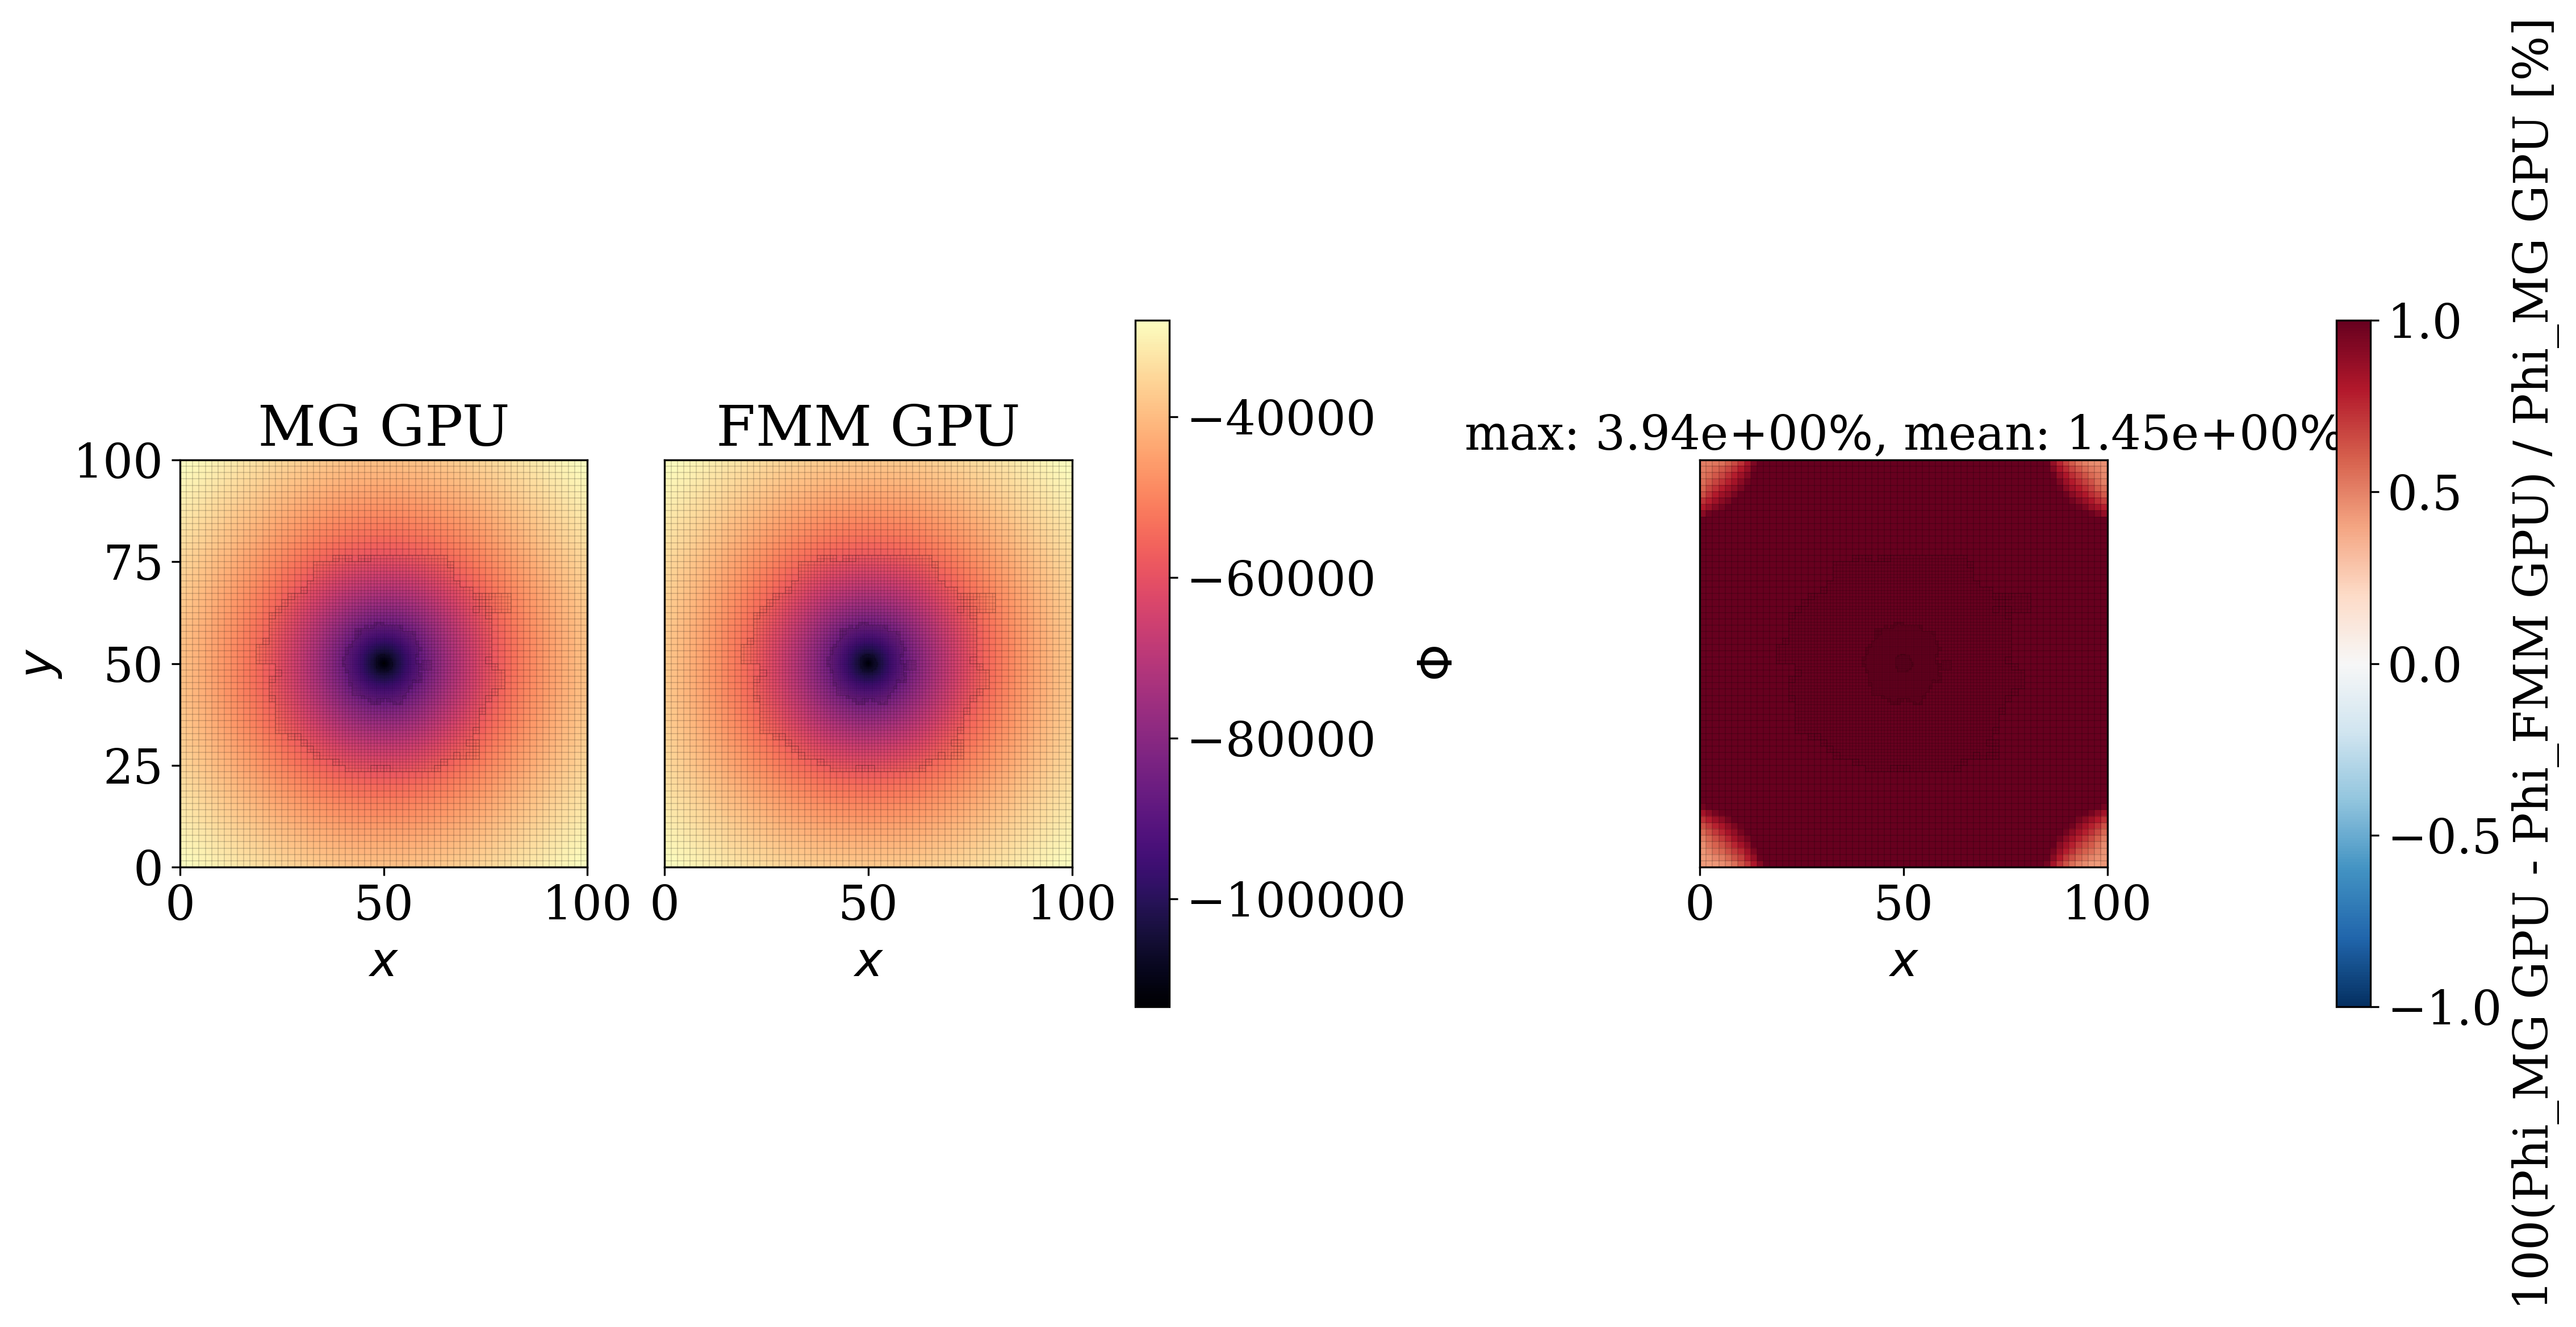

In [34]:
# FMM vs MG AMR comparison.
# Change solver_side to "cpu" to compare the CPU/MPI outputs instead.
solver_side = "gpu"

fmm_mg_paths = {
    "gpu": {
        "mg": "/home/jl4415/Ramses-FMM/halo_test/runs/9028480_mg_isolated/mg/output_00002/",
        "fmm": "/home/jl4415/Ramses-FMM/halo_test/runs/9024189_fmm_gpu_amr/fmm/output_00002/",
        "label": "GPU",
        "save": "fmm_mg_comparison_halo_gpu_amr.png",
    },
    "cpu": {
        "mg": "/home/jl4415/Ramses-FMM/halo_test/runs/manual_mg_cpu_amr/cpu/output_00002/",
        "fmm": "/home/jl4415/Ramses-FMM/halo_test/runs/8891572_fmm_mpi_amr/fmm/output_00002/",
        "label": "CPU/MPI",
        "save": "fmm_mg_comparison_halo_cpu_amr.png",
    },
}

case = fmm_mg_paths[solver_side]

fig, axes = panel_mpi_gpu_percent(
    gpu_output_path=case["fmm"],
    mpi_output_path=case["mg"],
    cen=100,
    field_index=0,
    diff_vmin=-1,
    diff_vmax=1,
    gpu_label=f"FMM {case['label']}",
    mpi_label=f"MG {case['label']}",
    save=case["save"],
)

Reading FMM CPU/MPI: /home/jl4415/Ramses-FMM/halo_test/runs/8891572_fmm_mpi_amr/fmm/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/8891572_fmm_mpi_amr/fmm/output_00002 (prefix='grav')
Reading MG CPU/MPI: /home/jl4415/Ramses-FMM/halo_test/runs/manual_mg_cpu_amr/cpu/output_00002/
I am reading nout:  00002
ncpu=1 ndim=3 nlevelmax=10
Time= 0.0002690410435564
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 499927 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/Ramses-FMM/halo_test/runs/manual_mg_cpu_amr/cpu/output_00002 (prefix='grav')
FMM CPU/MPI levels: [6 7 8 9]
MG CPU/MPI levels: [6 7 8 9]
Percent difference: 100 * (MG CPU/MPI - FMM CPU/MPI) / MG 

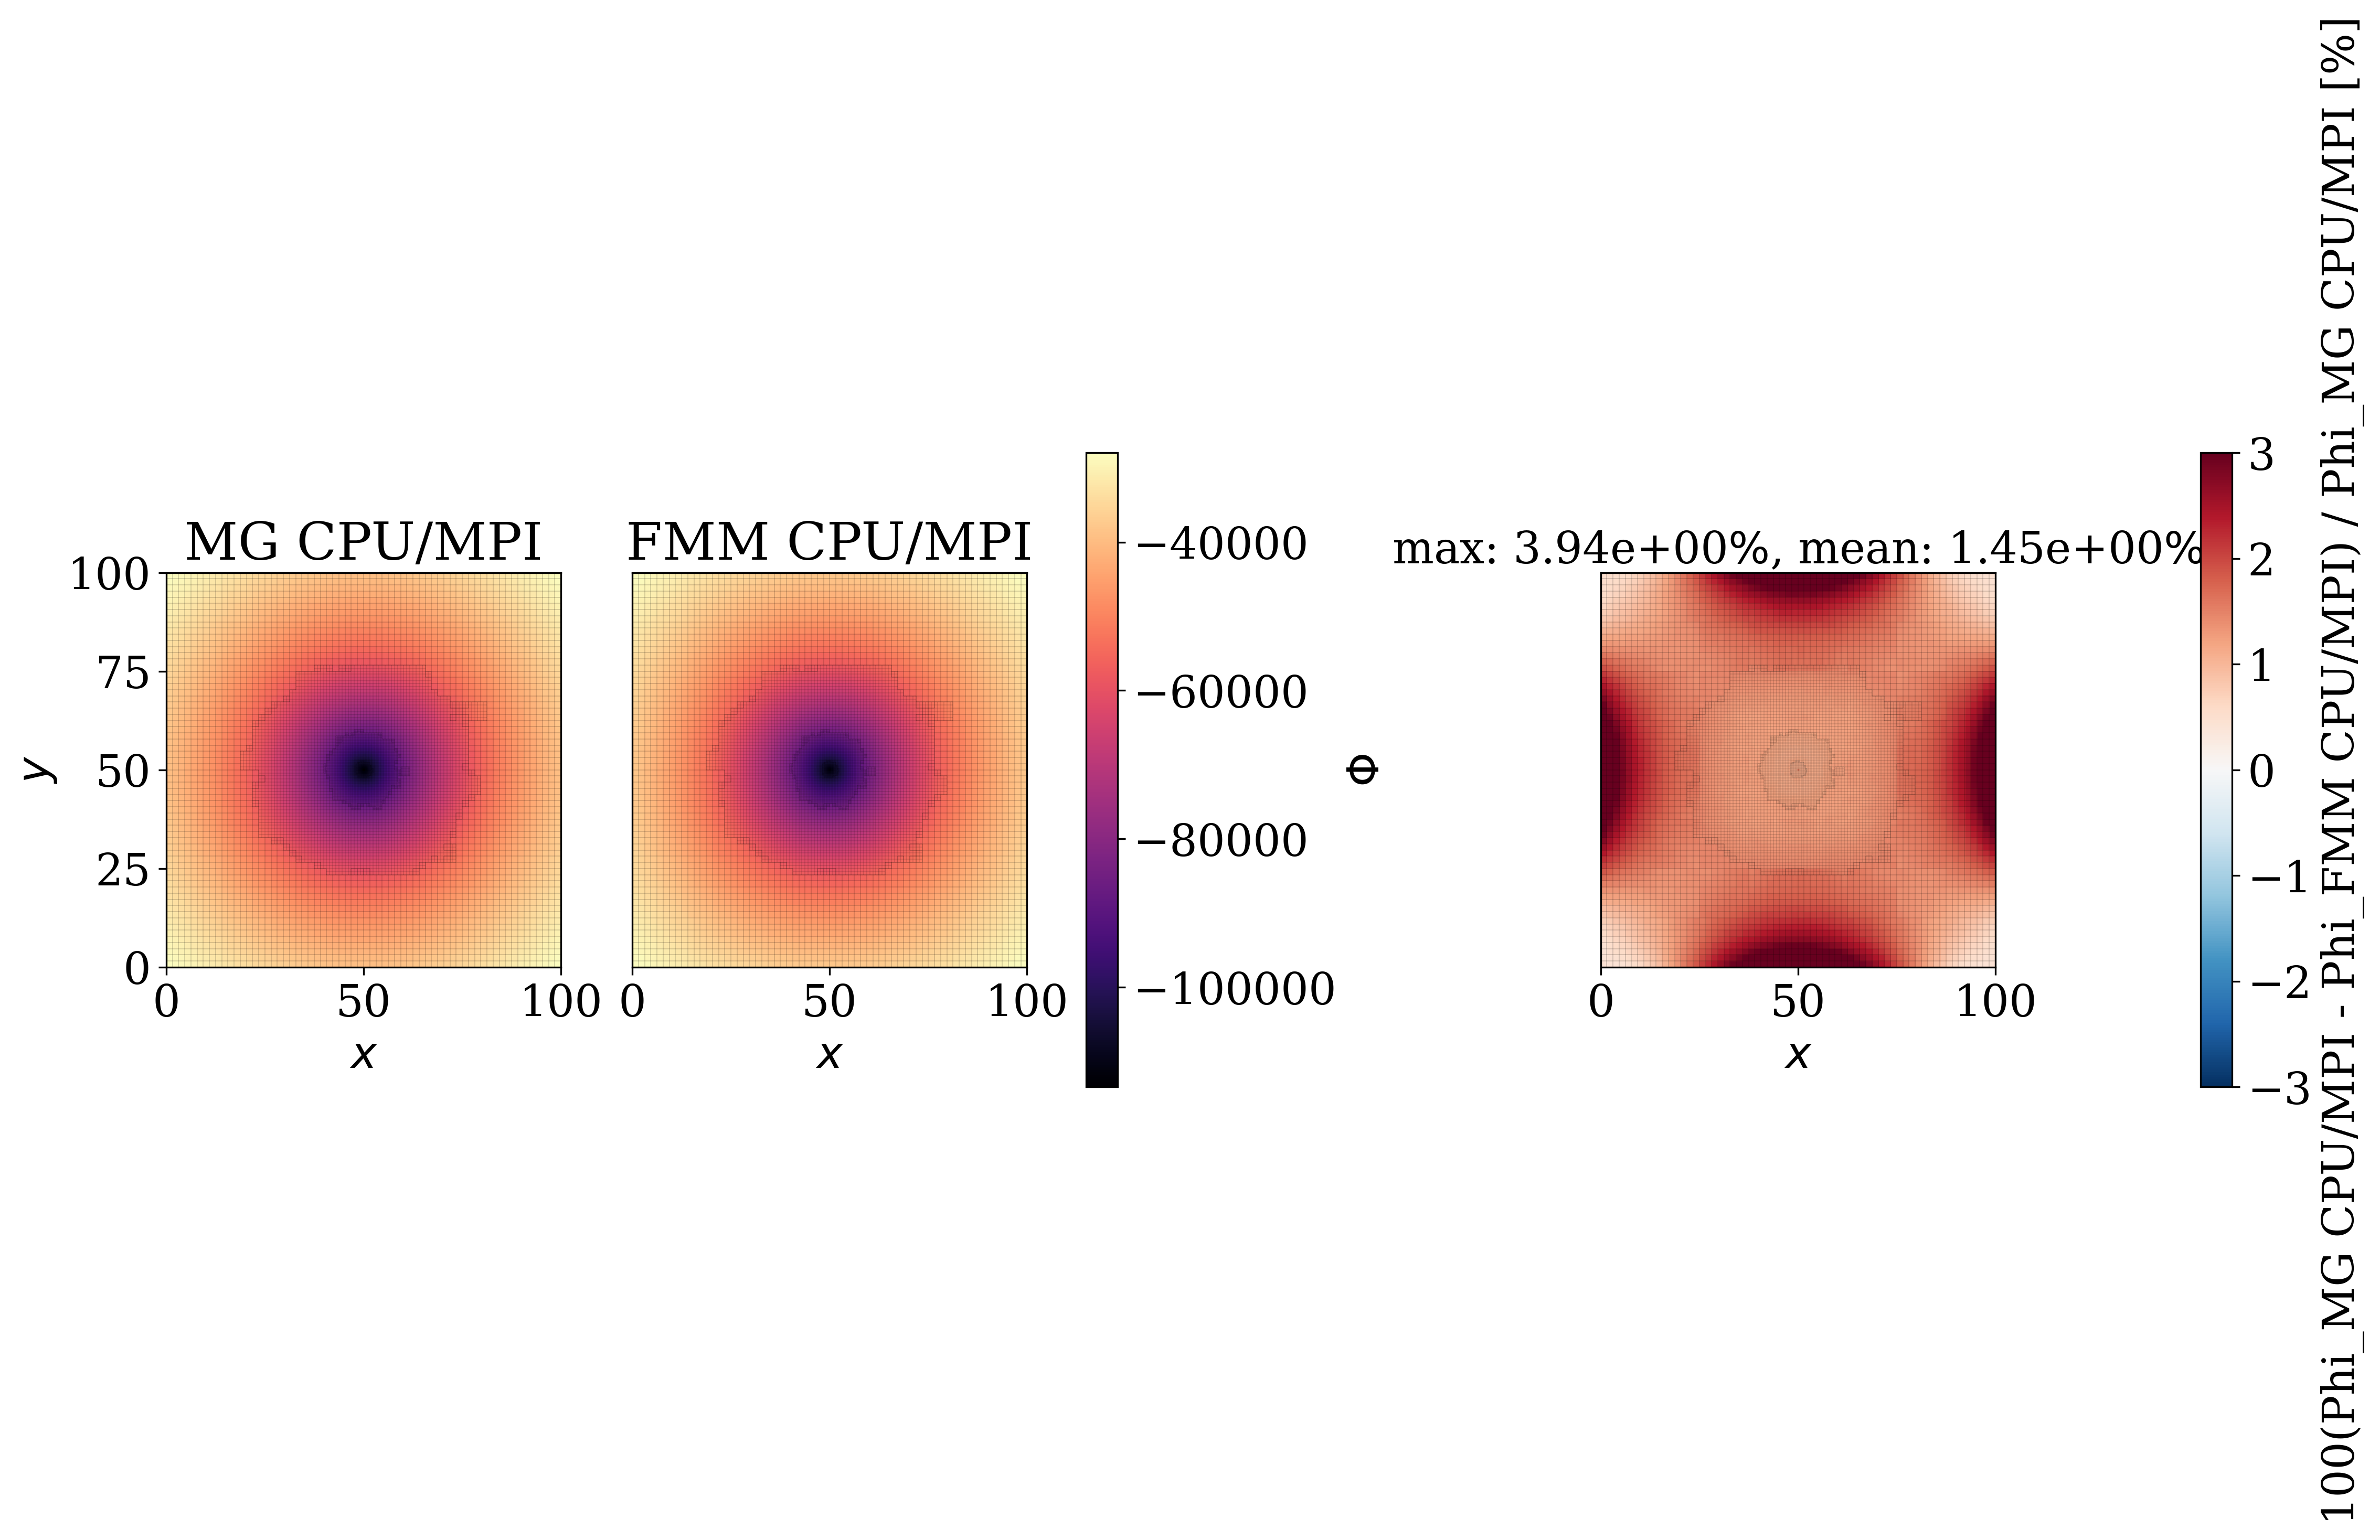

In [36]:
# FMM vs MG AMR comparison.
# Change solver_side to "cpu" to compare the CPU/MPI outputs instead.
solver_side = "cpu"

fmm_mg_paths = {
    "gpu": {
        "mg": "/home/jl4415/Ramses-FMM/halo_test/runs/9028480_mg_isolated/mg/output_00002/",
        "fmm": "/home/jl4415/Ramses-FMM/halo_test/runs/9024189_fmm_gpu_amr/fmm/output_00002/",
        "label": "GPU",
        "save": "fmm_mg_comparison_halo_gpu_amr.png",
    },
    "cpu": {
        "mg": "/home/jl4415/Ramses-FMM/halo_test/runs/manual_mg_cpu_amr/cpu/output_00002/",
        "fmm": "/home/jl4415/Ramses-FMM/halo_test/runs/8891572_fmm_mpi_amr/fmm/output_00002/",
        "label": "CPU/MPI",
        "save": "fmm_mg_comparison_halo_cpu_amr.png",
    },
}

case = fmm_mg_paths[solver_side]

fig, axes = panel_mpi_gpu_percent(
    gpu_output_path=case["fmm"],
    mpi_output_path=case["mg"],
    cen=100,
    field_index=0,
    diff_vmin=-3,
    diff_vmax=3,
    gpu_label=f"FMM {case['label']}",
    mpi_label=f"MG {case['label']}",
    save=case["save"],
)